In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

sys.path.append(os.path.abspath("./src"))

from pseudorandom_numbers import random
from fixed_point import fpi
from interpolations import interp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]  
    

## Psuedorandom Numbers

In almost every application in technology, you will find the use of "random number generators" somewhere.
They serve a variety of purposes from statistical analysis, to crytography, to video game "RNG."

But the issue with this need for randomness is that computers are binary. By design, they cannot generate 
random outcomes. As such, there are a varity of numerical methods which aim to acheive different levels of
randomness through various computations. None of these methods are truely random, but some are effective enough
that it would take millions of hours of compute to decrypt the next random number from a chain.

### Linear Congruential Generators

Among the simplest methods for generating pseudorandom numbers with an equal distribution is the Linear Congruential Generator, defined by the simple recursive function:

$$X_{n + 1} = (aX_{n} + c)\mod m$$

Where $m$, $a$, and $c$ are positive integers, $c$ and $m$ are coprime, $(a - 1)$ is a multiple of every prime factor of $m$ not equal to $m$, $m > a$ and $m > c$, and $X_0$ is some "seed" integer. (due to the $(a - 1)$ rule, $m$ is generally prime, but this is not strictly required)

The set of $\{X_{i}\}_{i \in N}$ where $N$ is the first $n$ positive integers is then a set of pseudorandom integers on the range $[0, m)$ with increment $c$ (hence why they have to be coprime to hit all possible integers on the range).

The function can be acheived computationally recursively fairly simply (where % is the modulo operator):

```python
def lcg(n):
    if n == 0:
        return x_0
    else:
        return (a * lcg(n - 1) + c) % m
```

The implimentation in the `task_one.py` script generates randomness using this equation where $m = 2^{16} + 1$, $a = 75$ and $c = 1$, and $X_0 = 1$, normalized to the range $[0, 1)$.

You can use the code block bellow generate psuedorandom numbers.

In [ ]:
random.lcg()

0.0011596502738910844

Using these numbers, we can see that the lcg equation generates random numbers from $[0, 1)$ on an interval of $1 / (2^{16} + 1)$ (which averages to $2^{-16}$ with 32-bit floating-point error at runtime). There is no skewed distribution or obious correlation between consecutive numbers. You can plot the charts bellow:

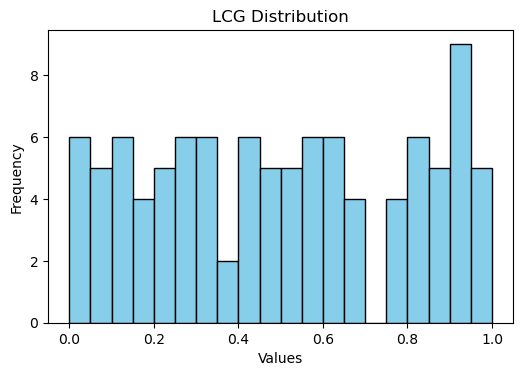

In [6]:
random.histogram(100)

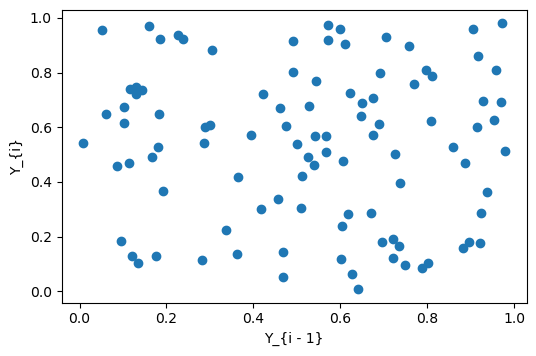

In [8]:
random.scatterplot(100)

But if we don't follow the rules stated above, that is not necissarily the case:

If $c$ and $m$ are not coprime, or $(a - 1)$ doesn't share prime factors with $m$, we get a stepwise linear output (the former leads to greater-than-one spacing, the ladder to correlation between consecutive outputs):

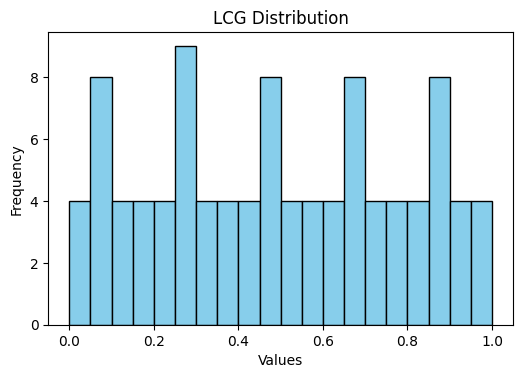

In [7]:
# c and m are not coprime:
random.histogram(100, m = 125, a = 6, c = 5)

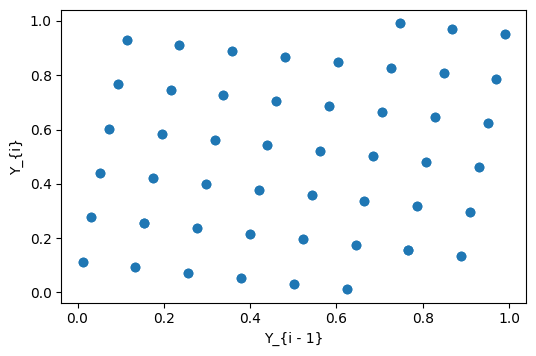

In [8]:
random.scatterplot(100, m = 343, a = 8, c = 7)

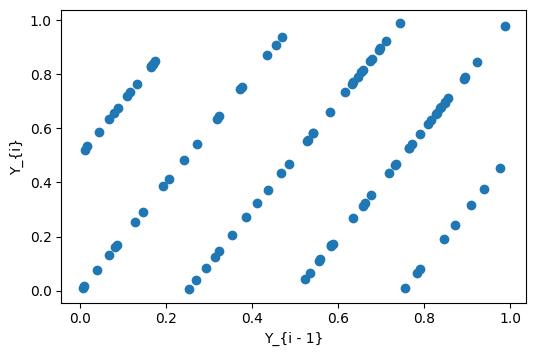

In [9]:
# (a - 1) doesn't share factors with m
random.scatterplot(100, m = 2018, a = 1011, c = 1)